In [17]:
from datasets import load_dataset

In [18]:
dataset_name = "Scicom-intl/semantic-vad-eot"
ds = load_dataset(
    dataset_name, 
    name="en", 
    split="train", 
    streaming=True
).shuffle(buffer_size=10000, seed=42).take(200)

In [19]:
n_spans_per_example = []
hold_durations = []
eot_durations = []

for example in ds:
    # per `iter_causal_examples` (semvad/data.py): sort by start, the last span
    # is `eot`, every earlier span is `hold`.
    spans = sorted(example["silence_spans"], key=lambda s: s["start"])
    n_spans_per_example.append(len(spans))
    for idx, span in enumerate(spans):
        duration = span["end"] - span["start"]
        (eot_durations if idx == len(spans) - 1 else hold_durations).append(duration)

len(n_spans_per_example), len(hold_durations), len(eot_durations)

(200, 130, 200)

In [20]:
import numpy as np
from collections import Counter

n_spans = np.array(n_spans_per_example)

# per `iter_causal_examples` (semvad/data.py): the last silence span in a turn
# is labeled `eot`, every earlier span is `hold` -- so each example contributes
# exactly one `eot` span and (n_spans - 1) `hold` spans.
eot_span_count = len(n_spans)
hold_span_count = int((n_spans - 1).sum())
total_span_count = eot_span_count + hold_span_count

print(f"examples: {len(n_spans)}")
print(f"total silence spans: {total_span_count}")
print(f"hold spans: {hold_span_count} ({hold_span_count / total_span_count:.1%})")
print(f"eot spans:  {eot_span_count} ({eot_span_count / total_span_count:.1%})")
print(f"examples with >1 span (i.e. contribute >=1 hold span): {(n_spans > 1).sum()} / {len(n_spans)}")
print("n_spans distribution:", dict(sorted(Counter(n_spans.tolist()).items())))

examples: 200
total silence spans: 330
hold spans: 130 (39.4%)
eot spans:  200 (60.6%)
examples with >1 span (i.e. contribute >=1 hold span): 74 / 200
n_spans distribution: {1: 126, 2: 41, 3: 19, 4: 9, 5: 3, 7: 2}


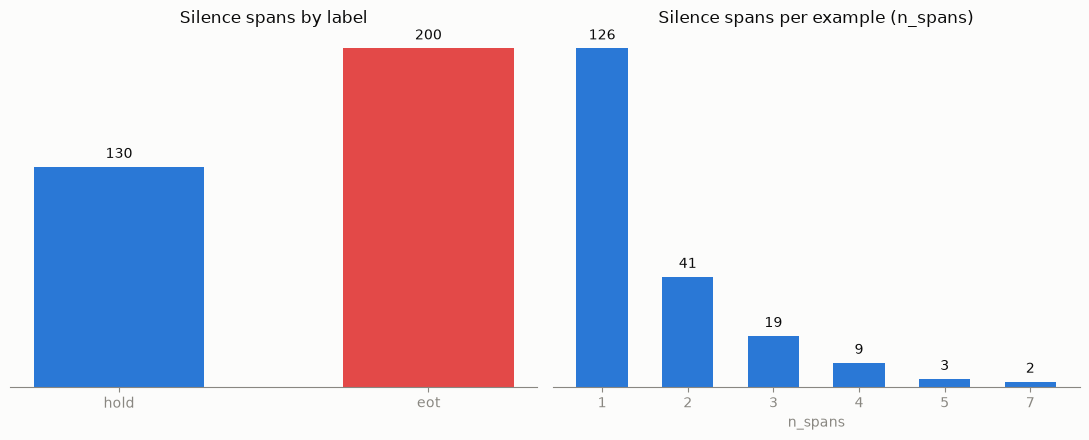

In [21]:
import matplotlib.pyplot as plt

surface, ink, muted = "#fcfcfb", "#0b0b0b", "#898781"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor=surface)

# left: hold vs eot span counts -- categorical, fixed order/colors
labels, counts = ["hold", "eot"], [hold_span_count, eot_span_count]
axes[0].set_facecolor(surface)
bars = axes[0].bar(labels, counts, color=["#2a78d6", "#e34948"], width=0.55)
axes[0].bar_label(bars, labels=[f"{c:,}" for c in counts], padding=4, color=ink)
axes[0].set_title("Silence spans by label", color=ink)
axes[0].tick_params(colors=muted)
axes[0].get_yaxis().set_visible(False)
for spine in ("top", "right", "left"):
    axes[0].spines[spine].set_visible(False)
axes[0].spines["bottom"].set_color(muted)

# right: distribution of n_spans per example -- single sequential hue
dist = Counter(n_spans.tolist())
xs = sorted(dist)
ys = [dist[x] for x in xs]
axes[1].set_facecolor(surface)
bars2 = axes[1].bar([str(x) for x in xs], ys, color="#2a78d6", width=0.6)
axes[1].bar_label(bars2, padding=4, color=ink)
axes[1].set_title("Silence spans per example (n_spans)", color=ink)
axes[1].set_xlabel("n_spans", color=muted)
axes[1].tick_params(colors=muted)
axes[1].get_yaxis().set_visible(False)
for spine in ("top", "right", "left"):
    axes[1].spines[spine].set_visible(False)
axes[1].spines["bottom"].set_color(muted)

plt.tight_layout()
plt.show()

In [22]:
hold_arr = np.array(hold_durations)
eot_arr = np.array(eot_durations)

def summarize(name, arr):
    print(
        f"{name}: n={len(arr)} mean={arr.mean():.3f}s median={np.median(arr):.3f}s "
        f"p10={np.percentile(arr, 10):.3f}s p90={np.percentile(arr, 90):.3f}s max={arr.max():.3f}s"
    )

summarize("hold", hold_arr)
summarize("eot", eot_arr)

hold: n=130 mean=0.360s median=0.305s p10=0.119s p90=0.721s max=0.990s
eot: n=200 mean=0.552s median=0.500s p10=0.500s p90=0.720s max=1.000s


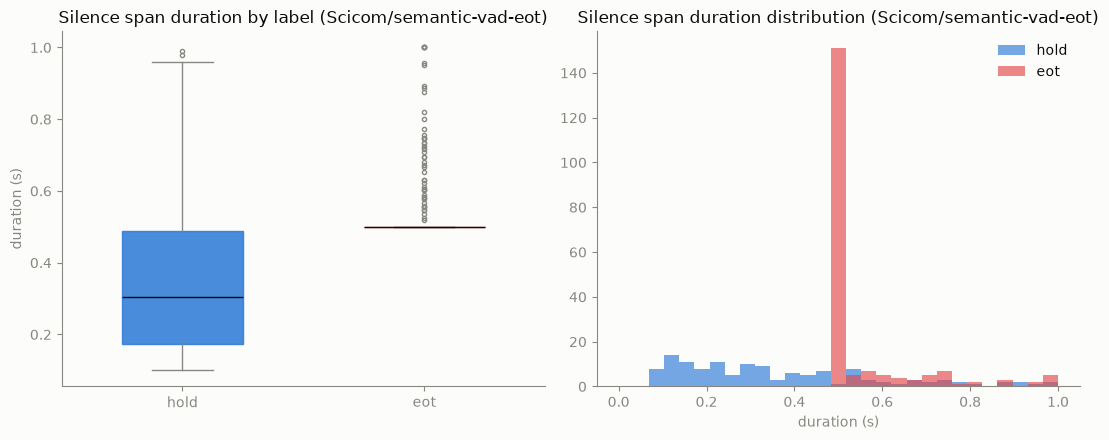

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor=surface)

# left: box plot of span duration by label -- same hold=blue/eot=red identity as
# the counts chart above (color follows the entity, not its rank)
axes[0].set_facecolor(surface)
bp = axes[0].boxplot(
    [hold_arr, eot_arr],
    tick_labels=["hold", "eot"],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color=ink),
    whiskerprops=dict(color=muted),
    capprops=dict(color=muted),
    flierprops=dict(markeredgecolor=muted, markersize=3),
)
for patch, color in zip(bp["boxes"], ["#2a78d6", "#e34948"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(color)
axes[0].set_title("Silence span duration by label (Scicom/semantic-vad-eot)", color=ink)
axes[0].set_ylabel("duration (s)", color=muted)
axes[0].tick_params(colors=muted)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].spines["left"].set_color(muted)
axes[0].spines["bottom"].set_color(muted)

# right: overlaid duration histograms -- 2 series, so a legend is mandatory
axes[1].set_facecolor(surface)
bins = np.linspace(0, max(hold_arr.max(), eot_arr.max()), 30)
axes[1].hist(hold_arr, bins=bins, color="#2a78d6", alpha=0.65, label="hold")
axes[1].hist(eot_arr, bins=bins, color="#e34948", alpha=0.65, label="eot")
axes[1].set_title("Silence span duration distribution (Scicom/semantic-vad-eot)", color=ink)
axes[1].set_xlabel("duration (s)", color=muted)
axes[1].tick_params(colors=muted)
axes[1].legend(frameon=False, labelcolor=ink)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_color(muted)
axes[1].spines["bottom"].set_color(muted)

plt.tight_layout()
plt.show()

## Compare against `livekit/eot-bench-data` (en, validation)

Same causal-labeling rule (last span per turn = `eot`, earlier spans = `hold`) applied to a different dataset, to check whether the training set's hold/eot balance and span-duration distributions generalize.

In [24]:
bench_dataset_name = "livekit/eot-bench-data"
ds_bench = load_dataset(
    bench_dataset_name,
    name="en",
    split="validation",
    streaming=True,
).shuffle(buffer_size=200, seed=42).take(200)

bench_n_spans_per_example = []
bench_hold_durations = []
bench_eot_durations = []

for example in ds_bench:
    spans = sorted(example["silence_spans"], key=lambda s: s["start"])
    bench_n_spans_per_example.append(len(spans))
    for idx, span in enumerate(spans):
        duration = span["end"] - span["start"]
        (bench_eot_durations if idx == len(spans) - 1 else bench_hold_durations).append(duration)

len(bench_n_spans_per_example), len(bench_hold_durations), len(bench_eot_durations)

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/livekit/eot-bench-data/resolve/35a1aec3f859527a0eb1dd6d22f6146e4ca3e2e5/data/en/validation-00000-of-00001.parquet
Retrying in 1s [Retry 1/5].


(200, 394, 200)

In [25]:
bench_n_spans = np.array(bench_n_spans_per_example)
bench_eot_span_count = len(bench_n_spans)
bench_hold_span_count = int((bench_n_spans - 1).sum())
bench_total_span_count = bench_eot_span_count + bench_hold_span_count

print(f"examples: {len(bench_n_spans)}")
print(f"total silence spans: {bench_total_span_count}")
print(f"hold spans: {bench_hold_span_count} ({bench_hold_span_count / bench_total_span_count:.1%})")
print(f"eot spans:  {bench_eot_span_count} ({bench_eot_span_count / bench_total_span_count:.1%})")
print(f"examples with >1 span: {(bench_n_spans > 1).sum()} / {len(bench_n_spans)}")
print("n_spans distribution:", dict(sorted(Counter(bench_n_spans.tolist()).items())))

examples: 200
total silence spans: 594
hold spans: 394 (66.3%)
eot spans:  200 (33.7%)
examples with >1 span: 108 / 200
n_spans distribution: {1: 92, 2: 29, 3: 21, 4: 18, 5: 10, 6: 9, 7: 2, 8: 4, 9: 4, 10: 6, 11: 2, 13: 1, 14: 2}


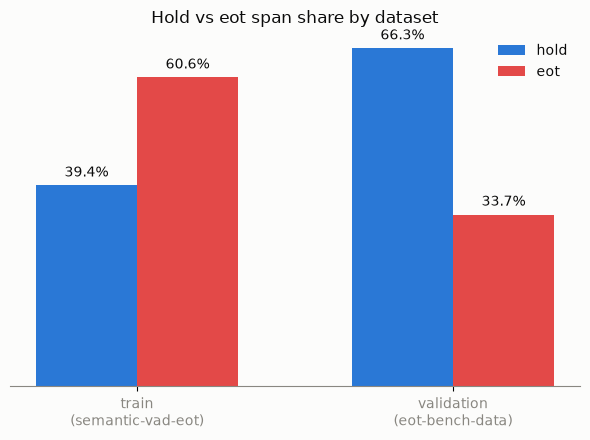

In [26]:
fig, ax = plt.subplots(figsize=(6, 4.5), facecolor=surface)
ax.set_facecolor(surface)

group_labels = ["train\n(semantic-vad-eot)", "validation\n(eot-bench-data)"]
hold_pct = [hold_span_count / total_span_count * 100, bench_hold_span_count / bench_total_span_count * 100]
eot_pct = [eot_span_count / total_span_count * 100, bench_eot_span_count / bench_total_span_count * 100]

x = np.arange(len(group_labels))
width = 0.32
bars_hold = ax.bar(x - width / 2, hold_pct, width, color="#2a78d6", label="hold")
bars_eot = ax.bar(x + width / 2, eot_pct, width, color="#e34948", label="eot")
ax.bar_label(bars_hold, fmt="%.1f%%", padding=4, color=ink)
ax.bar_label(bars_eot, fmt="%.1f%%", padding=4, color=ink)
ax.set_xticks(x)
ax.set_xticklabels(group_labels, color=muted)
ax.set_title("Hold vs eot span share by dataset", color=ink)
ax.legend(frameon=False, labelcolor=ink)
ax.get_yaxis().set_visible(False)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(muted)

plt.tight_layout()
plt.show()

In [27]:
bench_hold_arr = np.array(bench_hold_durations)
bench_eot_arr = np.array(bench_eot_durations)

summarize("bench hold", bench_hold_arr)
summarize("bench eot", bench_eot_arr)

bench hold: n=394 mean=0.430s median=0.300s p10=0.100s p90=0.800s max=3.300s
bench eot: n=200 mean=1.500s median=1.500s p10=1.500s p90=1.500s max=1.500s


In [28]:
bench_eot_arr

array([1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5,
       1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.

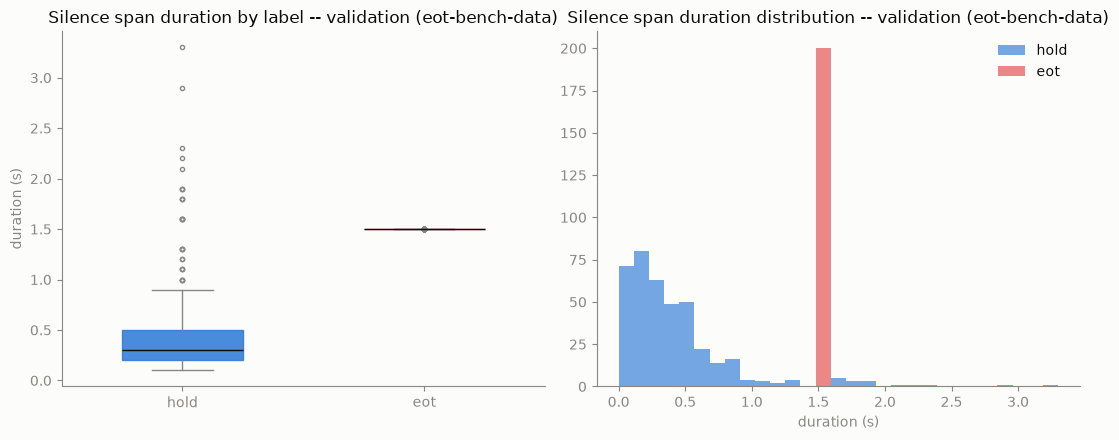

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor=surface)

# left: box plot of span duration by label -- same hold=blue/eot=red identity
axes[0].set_facecolor(surface)
bp = axes[0].boxplot(
    [bench_hold_arr, bench_eot_arr],
    tick_labels=["hold", "eot"],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color=ink),
    whiskerprops=dict(color=muted),
    capprops=dict(color=muted),
    flierprops=dict(markeredgecolor=muted, markersize=3),
)
for patch, color in zip(bp["boxes"], ["#2a78d6", "#e34948"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
    patch.set_edgecolor(color)
axes[0].set_title("Silence span duration by label -- validation (eot-bench-data)", color=ink)
axes[0].set_ylabel("duration (s)", color=muted)
axes[0].tick_params(colors=muted)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].spines["left"].set_color(muted)
axes[0].spines["bottom"].set_color(muted)

# right: overlaid duration histograms
axes[1].set_facecolor(surface)
bench_bins = np.linspace(0, max(bench_hold_arr.max(), bench_eot_arr.max()), 30)
axes[1].hist(bench_hold_arr, bins=bench_bins, color="#2a78d6", alpha=0.65, label="hold")
axes[1].hist(bench_eot_arr, bins=bench_bins, color="#e34948", alpha=0.65, label="eot")
axes[1].set_title("Silence span duration distribution -- validation (eot-bench-data)", color=ink)
axes[1].set_xlabel("duration (s)", color=muted)
axes[1].tick_params(colors=muted)
axes[1].legend(frameon=False, labelcolor=ink)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_color(muted)
axes[1].spines["bottom"].set_color(muted)

plt.tight_layout()
plt.show()

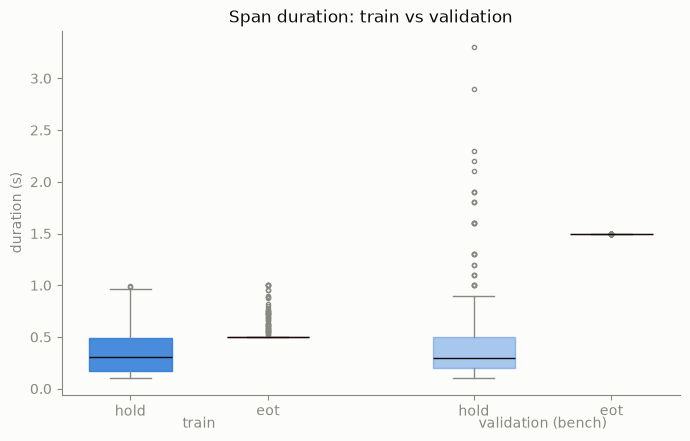

In [30]:
fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=surface)
ax.set_facecolor(surface)

data = [hold_arr, eot_arr, bench_hold_arr, bench_eot_arr]
positions = [1, 2, 3.5, 4.5]
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=True,
    medianprops=dict(color=ink),
    whiskerprops=dict(color=muted),
    capprops=dict(color=muted),
    flierprops=dict(markeredgecolor=muted, markersize=3),
)
# same hold=blue/eot=red identity throughout; the validation set's boxes are
# lower-alpha so the two datasets stay visually distinct without a 3rd hue
colors = ["#2a78d6", "#e34948", "#2a78d6", "#e34948"]
alphas = [0.85, 0.85, 0.4, 0.4]
for patch, color, alpha in zip(bp["boxes"], colors, alphas):
    patch.set_facecolor(color)
    patch.set_alpha(alpha)
    patch.set_edgecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(["hold", "eot", "hold", "eot"], color=muted)
ax.set_ylabel("duration (s)", color=muted)
ax.set_title("Span duration: train vs validation", color=ink)
ax.text(1.5, -0.09, "train", transform=ax.get_xaxis_transform(), ha="center", color=muted)
ax.text(4.0, -0.09, "validation (bench)", transform=ax.get_xaxis_transform(), ha="center", color=muted)
ax.tick_params(colors=muted)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(muted)
ax.spines["bottom"].set_color(muted)

plt.tight_layout()
plt.show()